In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
#read in the csv file 
df = pd.read_csv(r'C:\Users\micha\Documents\DATA ANALYSIS\Python Projects\2026_f1_season_standings_predictor\results.csv')
df.head()

,number,position,positionText,points,grid,laps,status,Driver.driverId,Driver.permanentNumber,Driver.code,...,FastestLap.rank,FastestLap.lap,FastestLap.Time.time,FastestLap.AverageSpeed.units,FastestLap.AverageSpeed.speed,season,round,raceName,date,Circuit.circuitId
0,16,1,1,26,1,57,Finished,leclerc,16,LEC,...,1.0,51.0,1:34.570,kph,206.018,2022,1,Bahrain Grand Prix,2022-03-20,bahrain
1,55,2,2,18,3,57,Finished,sainz,55,SAI,...,3.0,52.0,1:35.740,kph,203.501,2022,1,Bahrain Grand Prix,2022-03-20,bahrain
2,44,3,3,15,5,57,Finished,hamilton,44,HAM,...,5.0,53.0,1:36.228,kph,202.469,2022,1,Bahrain Grand Prix,2022-03-20,bahrain
3,63,4,4,12,9,57,Finished,russell,63,RUS,...,6.0,56.0,1:36.302,kph,202.313,2022,1,Bahrain Grand Prix,2022-03-20,bahrain
4,20,5,5,10,7,57,Finished,kevin_magnussen,20,MAG,...,8.0,53.0,1:36.623,kph,201.641,2022,1,Bahrain Grand Prix,2022-03-20,bahrain


### Understanding the shape of the data

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1970 entries, 0 to 1969
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   number                         1970 non-null   int64  
 1   position                       1970 non-null   int64  
 2   positionText                   1970 non-null   object 
 3   points                         1970 non-null   int64  
 4   grid                           1970 non-null   int64  
 5   laps                           1970 non-null   int64  
 6   status                         1970 non-null   object 
 7   Driver.driverId                1970 non-null   object 
 8   Driver.permanentNumber         1970 non-null   int64  
 9   Driver.code                    1970 non-null   object 
 10  Driver.url                     1970 non-null   object 
 11  Driver.givenName               1970 non-null   object 
 12  Driver.familyName              1970 non-null   o

In [22]:
df.describe

<bound method NDFrame.describe of       number  position positionText  points  grid  laps    status  \
0         16         1            1      26     1    57  Finished   
1         55         2            2      18     3    57  Finished   
2         44         3            3      15     5    57  Finished   
3         63         4            4      12     9    57  Finished   
4         20         5            5      10     7    57  Finished   
...      ...       ...          ...     ...   ...   ...       ...   
1965      18        18            R       0    22    56   Retired   
1966       1        19            R       0     8    43   Retired   
1967      87        20            R       0    19    27   Retired   
1968      77        21            R       0    20    15   Retired   
1969       3        22            R       0     2     0   Retired   

      Driver.driverId  Driver.permanentNumber Driver.code  ...  \
0             leclerc                      16         LEC  ...   
1    

### Checking and removing any missing values or duplicates where applicable

In [23]:
#checking for missing values
df.isna().sum().sort_values(ascending=False)

FastestLap.AverageSpeed.speed    685
FastestLap.AverageSpeed.units    685
Time.time                        372
Time.millis                      346
FastestLap.Time.time              74
FastestLap.lap                    74
FastestLap.rank                   74
number                             0
Constructor.url                    0
date                               0
raceName                           0
round                              0
season                             0
Constructor.nationality            0
Constructor.name                   0
Constructor.constructorId          0
position                           0
Driver.nationality                 0
Driver.dateOfBirth                 0
Driver.familyName                  0
Driver.givenName                   0
Driver.url                         0
Driver.code                        0
Driver.permanentNumber             0
Driver.driverId                    0
status                             0
laps                               0
g

In [24]:
df['FastestLap.AverageSpeed.speed']

0       206.018
1       203.501
2       202.469
3       202.313
4       201.641
         ...   
1965        NaN
1966        NaN
1967        NaN
1968        NaN
1969        NaN
Name: FastestLap.AverageSpeed.speed, Length: 1970, dtype: float64

Given the nature of the data, it doesn't make sense to remove any of the missing values. This is because the missing values only highlight the fact that these drivers did not manage to get a fastest lap during a race or even if they did, they did not finish in the top 10.

### Validating driver and constructor data

In [25]:
#check that each row represents one driver for each race
df.duplicated().sum()
df.groupby(['season', 'round', 'Driver.driverId']).size().max()

1

In [26]:
#check each race has about 20 drivers
df.groupby(['season', 'round'])['Driver.driverId'].nunique().max()

22

In [27]:
df['Constructor.constructorId'].unique()

array(['ferrari', 'mercedes', 'haas', 'alfa', 'alpine', 'alphatauri',
       'aston_martin', 'williams', 'mclaren', 'red_bull', 'sauber', 'rb',
       'audi', 'cadillac'], dtype=object)

Something important to note, is that some teams have changed their names. Alphatauri became Racing Bulls (RB). Also Alfaromeo became Sauber, which was then purchased by Audi, with Audi beginning in the 2026 season.

In [28]:
#combining the data for these teams
updated_constructor_names = {
    'alphatauri': 'rb',
    'alfa': 'audi',
    'sauber': 'audi'
}

#creating modified column
df['constructor_names'] = (df['Constructor.constructorId'].replace(updated_constructor_names))
df

,number,position,positionText,points,grid,laps,status,Driver.driverId,Driver.permanentNumber,Driver.code,...,FastestLap.lap,FastestLap.Time.time,FastestLap.AverageSpeed.units,FastestLap.AverageSpeed.speed,season,round,raceName,date,Circuit.circuitId,constructor_names
0,16,1,1,26,1,57,Finished,leclerc,16,LEC,...,51.0,1:34.570,kph,206.018,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,ferrari
1,55,2,2,18,3,57,Finished,sainz,55,SAI,...,52.0,1:35.740,kph,203.501,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,ferrari
2,44,3,3,15,5,57,Finished,hamilton,44,HAM,...,53.0,1:36.228,kph,202.469,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,mercedes
3,63,4,4,12,9,57,Finished,russell,63,RUS,...,56.0,1:36.302,kph,202.313,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,mercedes
4,20,5,5,10,7,57,Finished,kevin_magnussen,20,MAG,...,53.0,1:36.623,kph,201.641,2022,1,Bahrain Grand Prix,2022-03-20,bahrain,haas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1965,18,18,R,0,22,56,Retired,stroll,18,STR,...,36.0,1:18.845,NaN,NaN,2026,6,Monaco Grand Prix,2026-06-07,monaco,aston_martin
1966,1,19,R,0,8,43,Retired,norris,1,NOR,...,34.0,1:17.670,NaN,NaN,2026,6,Monaco Grand Prix,2026-06-07,monaco,mclaren
1967,87,20,R,0,19,27,Retired,bearman,87,BEA,...,22.0,1:18.475,NaN,NaN,2026,6,Monaco Grand Prix,2026-06-07,monaco,haas
1968,77,21,R,0,20,15,Retired,bottas,77,BOT,...,8.0,1:20.494,NaN,NaN,2026,6,Monaco Grand Prix,2026-06-07,monaco,cadillac


In [29]:
#confirming each team began in 2022 upto the current season in 2026, after including past performances even under different names
df.groupby('constructor_names')['season'].agg(['min', 'max', 'nunique'])

,min,max,nunique
constructor_names,,,
alpine,2022,2026,5
aston_martin,2022,2026,5
audi,2022,2026,5
cadillac,2026,2026,1
ferrari,2022,2026,5
haas,2022,2026,5
mclaren,2022,2026,5
mercedes,2022,2026,5
rb,2022,2026,5


In [30]:
#make sure that at most only 24 cars are at any given race
assert df['grid'].between(0, 24).all()
#make sure that any driver recieves at most 26 points
assert df['points'].between(0, 26).all()

In [78]:
#export modified data
df.to_csv('cleaned_results.csv')

## Exploratory Data Analysis

### Overall team and driver performance statistics

This will be used to determine what teams and drivers in F1, between 2022 and 2026 have been the most successful. The reason for this is to determine what the general 'pecking' order for the standings could potentially look like given that more often than not in F1, the best teams stay at the top, while the teams that struggle stay at the bottom. This however does not apply to drivers, as to a certain extent, the drivers team has a significant role in the success of the driver

In [32]:
#drivers with the most wins overall
df[df['position']==1].groupby('Driver.driverId').size().sort_values(ascending=False)

Driver.driverId
max_verstappen    51
norris            11
piastri            9
leclerc            6
russell            6
antonelli          5
perez              4
sainz              4
hamilton           2
dtype: int64

In [35]:
#driver with the most wins in every season
df[df['position']==1].groupby(['season', 'Driver.driverId']).size().reset_index(name='wins').sort_values(['season', 'wins'], ascending=[False, False])

,season,Driver.driverId,wins
19,2026,antonelli,5
20,2026,russell,1
15,2025,max_verstappen,8
16,2025,norris,7
17,2025,piastri,7
18,2025,russell,2
10,2024,max_verstappen,9
11,2024,norris,4
9,2024,leclerc,3
8,2024,hamilton,2


In [36]:
#average qualifying performace for each driver
df.groupby('Driver.driverId')['grid'].mean().sort_values()

Driver.driverId
max_verstappen      3.724490
leclerc             4.918367
russell             5.295918
norris              5.469388
piastri             5.855263
antonelli           7.266667
sainz               7.463918
hamilton            7.591837
perez               8.797297
alonso              9.622449
hadjar              9.633333
gasly              12.020408
arvid_lindblad     12.333333
ricciardo          12.404255
tsunoda            12.445652
lawson             12.512195
vettel             12.600000
ocon               12.773196
hulkenberg         12.974359
mick_schumacher    13.136364
albon              13.443299
bottas             13.702703
stroll             13.865979
kevin_magnussen    13.924242
bearman            14.060606
bortoleto          14.200000
zhou               15.588235
colapinto          15.606061
doohan             15.714286
de_vries           15.818182
sargeant           16.944444
latifi             17.500000
Name: grid, dtype: float64

In [37]:
#average qualifying performance for each driver in each season
df.groupby(['season', 'Driver.driverId'])['grid'].mean()

season  Driver.driverId
2022    albon              15.619048
        alonso              9.409091
        bottas             10.454545
        de_vries            8.000000
        gasly              10.772727
                             ...    
2026    perez              19.333333
        piastri             5.166667
        russell             2.833333
        sainz              15.666667
        stroll             21.000000
Name: grid, Length: 111, dtype: float64

In [38]:
#expected points per driver
df.groupby(['season', 'Driver.driverId'])['points'].mean()

season  Driver.driverId
2022    albon               0.190476
        alonso              3.681818
        bottas              2.136364
        de_vries            2.000000
        gasly               1.045455
                             ...    
2026    perez               0.000000
        piastri             7.166667
        russell            11.166667
        sainz               1.000000
        stroll              0.000000
Name: points, Length: 111, dtype: float64

In [39]:
#expected points per constructor in each season
df.groupby(['season', 'Constructor.constructorId'])['points'].sum()

season  Constructor.constructorId
2022    alfa                          53
        alphatauri                    35
        alpine                       170
        aston_martin                  55
        ferrari                      519
        haas                          33
        mclaren                      150
        mercedes                     495
        red_bull                     724
        williams                       8
2023    alfa                          16
        alphatauri                    22
        alpine                       110
        aston_martin                 266
        ferrari                      363
        haas                           9
        mclaren                      266
        mercedes                     374
        red_bull                     790
        williams                      26
2024    alpine                        63
        aston_martin                  94
        ferrari                      595
        haas           

In terms of the overall team performance, since the 2022 season, there has been more of less a pecking order of the teams in F1, where the big teams; Redbull, Mercedes, Ferrari remain consistently in the top 4, however, that changed in 2024, with Mclaren joining that 'club'. The midfield teams have been more volatile, as some teams like Aston Martin have watched their form collapse year on year, while Williams who struggled as a back marker had an incredible season in 2025. This is the same with the back markers as well, as it tends to change drastically like when Alpine went from a mid-table team, to the worst team on the grid in 2025. This would make it harder to predict the "middle" portion of the standings, while last place may be easier given a new team with no F1 experience; Cadillac, joined in 2026.

In [52]:
#comparing the win rate, and the race completion rate of each driver
df['finished'] = df['status'].str.contains('Finished|Lap', case=False, na=False).astype(int)

stats = df.groupby('Driver.driverId').agg(
    race_entries = ('position', 'size'),
    wins = ('position', lambda x: (x == 1).sum()),
    finished = ('finished', 'sum')
)
#win rate for each driver
stats['win_rate'] = round((stats['wins'] / stats['race_entries']) * 100, 2)
#finish rate for each driver
stats['finished_rate'] = round((stats['finished'] / stats['race_entries']) * 100, 2)
stats

,race_entries,wins,finished,win_rate,finished_rate
Driver.driverId,,,,,
albon,97,0,75,0.00,77.32
alonso,98,0,81,0.00,82.65
antonelli,30,5,26,16.67,86.67
arvid_lindblad,6,0,5,0.00,83.33
bearman,33,0,28,0.00,84.85
bortoleto,30,0,24,0.00,80.00
bottas,74,0,61,0.00,82.43
colapinto,33,0,29,0.00,87.88
de_vries,11,0,9,0.00,81.82


This portion looks at how a drivers position changes as the season progresses. In this section, if null values appear in a drivers column, it means that the driver was one, not a part of the season, or it means the driver was replaced, or that the driver had to miss a race due to unusual circumstances

In [84]:
#changes in a drivers performance as a season progresses in 2025
driver_season_2025 = df[df['season']==2025]
driver_pivot = driver_season_2025.pivot(
    index='round',
    columns='Driver.driverId',
    values='position'
)
driver_pivot

Driver.driverId,albon,alonso,antonelli,bearman,bortoleto,colapinto,doohan,gasly,hadjar,hamilton,...,lawson,leclerc,max_verstappen,norris,ocon,piastri,russell,sainz,stroll,tsunoda
round,,,,,,,,,,,,,,,,,,,,,
1,5.0,17.0,4.0,14.0,16.0,NaN,19.0,11.0,20.0,10.0,...,15.0,8.0,2.0,1.0,13.0,9.0,3.0,18.0,6.0,12.0
2,7.0,17.0,6.0,8.0,14.0,NaN,13.0,20.0,11.0,19.0,...,12.0,18.0,4.0,2.0,5.0,1.0,3.0,10.0,9.0,16.0
3,9.0,11.0,6.0,10.0,19.0,NaN,15.0,13.0,8.0,7.0,...,17.0,4.0,1.0,2.0,18.0,3.0,5.0,14.0,20.0,12.0
4,12.0,15.0,11.0,10.0,18.0,NaN,14.0,7.0,13.0,5.0,...,16.0,4.0,6.0,3.0,8.0,1.0,2.0,19.0,17.0,9.0
5,9.0,11.0,6.0,13.0,18.0,NaN,17.0,20.0,10.0,7.0,...,12.0,3.0,2.0,4.0,14.0,1.0,5.0,8.0,16.0,19.0
6,5.0,15.0,6.0,19.0,18.0,NaN,20.0,13.0,11.0,8.0,...,17.0,7.0,4.0,2.0,12.0,1.0,3.0,9.0,16.0,10.0
7,5.0,11.0,19.0,17.0,18.0,16.0,NaN,13.0,9.0,4.0,...,14.0,6.0,1.0,2.0,20.0,3.0,7.0,8.0,15.0,10.0
8,9.0,19.0,18.0,12.0,14.0,13.0,NaN,20.0,6.0,5.0,...,8.0,2.0,4.0,1.0,7.0,3.0,11.0,10.0,15.0,17.0
9,19.0,9.0,18.0,17.0,12.0,15.0,NaN,8.0,7.0,6.0,...,11.0,3.0,10.0,2.0,16.0,1.0,4.0,14.0,NaN,13.0


Something important to note would be the missing values for Colapinto in the first 6 races, and the missing values for Doohan in the remaining 18 races. This is because Alpine decided to change their driver lineup after 6 races into the season, where they replaces Doohan with Colapinto

Repeating the same for the 2022-2024 seasons

In [85]:
#changes in a drivers performance as a season progresses in 2022
driver_season_2024 = df[df['season']==2024]
driver_pivot = driver_season_2024.pivot(
    index='round',
    columns='Driver.driverId',
    values='position'
)
driver_pivot

Driver.driverId,albon,alonso,bearman,bottas,colapinto,doohan,gasly,hamilton,hulkenberg,kevin_magnussen,...,ocon,perez,piastri,ricciardo,russell,sainz,sargeant,stroll,tsunoda,zhou
round,,,,,,,,,,,,,,,,,,,,,
1,15.0,9.0,NaN,19.0,NaN,NaN,18.0,7.0,16.0,12.0,...,17.0,2.0,8.0,13.0,5.0,3.0,20.0,10.0,14.0,11.0
2,11.0,5.0,7.0,17.0,NaN,NaN,20.0,9.0,10.0,12.0,...,13.0,2.0,4.0,16.0,6.0,NaN,14.0,19.0,15.0,18.0
3,11.0,8.0,NaN,14.0,NaN,NaN,13.0,18.0,9.0,10.0,...,16.0,5.0,4.0,12.0,17.0,1.0,NaN,6.0,7.0,15.0
4,20.0,6.0,NaN,14.0,NaN,NaN,16.0,9.0,11.0,13.0,...,15.0,2.0,8.0,19.0,7.0,3.0,17.0,12.0,10.0,18.0
5,12.0,7.0,NaN,20.0,NaN,NaN,13.0,9.0,10.0,16.0,...,11.0,3.0,8.0,18.0,6.0,5.0,17.0,15.0,19.0,14.0
6,18.0,9.0,NaN,16.0,NaN,NaN,12.0,6.0,11.0,19.0,...,10.0,4.0,13.0,15.0,8.0,5.0,20.0,17.0,7.0,14.0
7,20.0,19.0,NaN,18.0,NaN,NaN,16.0,6.0,11.0,12.0,...,14.0,8.0,4.0,13.0,7.0,5.0,17.0,9.0,10.0,15.0
8,9.0,11.0,NaN,13.0,NaN,NaN,10.0,7.0,19.0,20.0,...,17.0,18.0,2.0,12.0,5.0,3.0,15.0,14.0,8.0,16.0
9,17.0,6.0,NaN,13.0,NaN,NaN,9.0,4.0,11.0,12.0,...,10.0,18.0,5.0,8.0,3.0,16.0,20.0,7.0,14.0,15.0


In [86]:
#changes in a drivers performance as a season progresses in 2023
driver_season_2023 = df[df['season']==2023]
driver_pivot = driver_season_2023.pivot(
    index='round',
    columns='Driver.driverId',
    values='position'
)
driver_pivot

Driver.driverId,albon,alonso,bottas,de_vries,gasly,hamilton,hulkenberg,kevin_magnussen,lawson,leclerc,...,ocon,perez,piastri,ricciardo,russell,sainz,sargeant,stroll,tsunoda,zhou
round,,,,,,,,,,,,,,,,,,,,,
1,10.0,3.0,8.0,14.0,9.0,5.0,15.0,13.0,NaN,19.0,...,18.0,2.0,20.0,NaN,7.0,4.0,12.0,6.0,11.0,16.0
2,19.0,3.0,18.0,14.0,9.0,5.0,12.0,10.0,NaN,7.0,...,8.0,1.0,15.0,NaN,4.0,6.0,16.0,20.0,11.0,13.0
3,19.0,3.0,11.0,15.0,13.0,2.0,7.0,17.0,NaN,20.0,...,14.0,5.0,8.0,NaN,18.0,12.0,16.0,4.0,10.0,9.0
4,12.0,4.0,18.0,20.0,14.0,6.0,17.0,13.0,NaN,3.0,...,15.0,1.0,11.0,NaN,8.0,5.0,16.0,7.0,10.0,19.0
5,14.0,3.0,13.0,18.0,8.0,6.0,15.0,10.0,NaN,7.0,...,9.0,2.0,19.0,NaN,4.0,5.0,20.0,12.0,11.0,16.0
6,14.0,2.0,11.0,12.0,7.0,4.0,17.0,19.0,NaN,6.0,...,3.0,16.0,10.0,NaN,5.0,8.0,18.0,20.0,15.0,13.0
7,16.0,7.0,19.0,14.0,10.0,2.0,15.0,18.0,NaN,11.0,...,8.0,4.0,13.0,NaN,3.0,5.0,20.0,6.0,12.0,9.0
8,7.0,2.0,10.0,18.0,12.0,3.0,15.0,17.0,NaN,4.0,...,8.0,6.0,11.0,NaN,19.0,5.0,20.0,9.0,14.0,16.0
9,11.0,5.0,15.0,17.0,10.0,8.0,20.0,18.0,NaN,2.0,...,14.0,3.0,16.0,NaN,7.0,6.0,13.0,9.0,19.0,12.0


In [87]:
#changes in a drivers performance as a season progresses in 2022
driver_season_2022 = df[df['season']==2022]
driver_pivot = driver_season_2022.pivot(
    index='round',
    columns='Driver.driverId',
    values='position'
)
driver_pivot

Driver.driverId,albon,alonso,bottas,de_vries,gasly,hamilton,hulkenberg,kevin_magnussen,latifi,leclerc,...,norris,ocon,perez,ricciardo,russell,sainz,stroll,tsunoda,vettel,zhou
round,,,,,,,,,,,,,,,,,,,,,
1,13.0,9.0,6.0,NaN,20.0,3.0,17.0,5.0,16.0,1.0,...,15.0,7.0,18.0,14.0,4.0,2.0,12.0,8.0,NaN,10.0
2,14.0,16.0,15.0,NaN,8.0,10.0,12.0,9.0,18.0,2.0,...,7.0,6.0,4.0,17.0,5.0,3.0,13.0,19.0,NaN,11.0
3,10.0,17.0,8.0,NaN,9.0,4.0,NaN,14.0,16.0,1.0,...,5.0,7.0,2.0,6.0,3.0,20.0,12.0,15.0,19.0,11.0
4,11.0,19.0,5.0,NaN,12.0,13.0,NaN,9.0,16.0,6.0,...,3.0,14.0,2.0,18.0,4.0,20.0,10.0,7.0,8.0,15.0
5,9.0,11.0,7.0,NaN,18.0,6.0,NaN,16.0,14.0,2.0,...,19.0,8.0,4.0,13.0,5.0,3.0,10.0,12.0,17.0,20.0
6,18.0,9.0,6.0,NaN,13.0,5.0,NaN,17.0,16.0,20.0,...,8.0,7.0,2.0,12.0,3.0,4.0,15.0,10.0,11.0,19.0
7,18.0,7.0,9.0,NaN,11.0,8.0,NaN,20.0,15.0,4.0,...,6.0,12.0,1.0,13.0,5.0,2.0,14.0,17.0,10.0,16.0
8,12.0,7.0,11.0,NaN,5.0,4.0,NaN,17.0,15.0,19.0,...,9.0,10.0,2.0,8.0,3.0,20.0,16.0,13.0,6.0,18.0
9,13.0,9.0,7.0,NaN,14.0,3.0,NaN,17.0,16.0,5.0,...,15.0,6.0,20.0,11.0,4.0,2.0,10.0,18.0,12.0,8.0


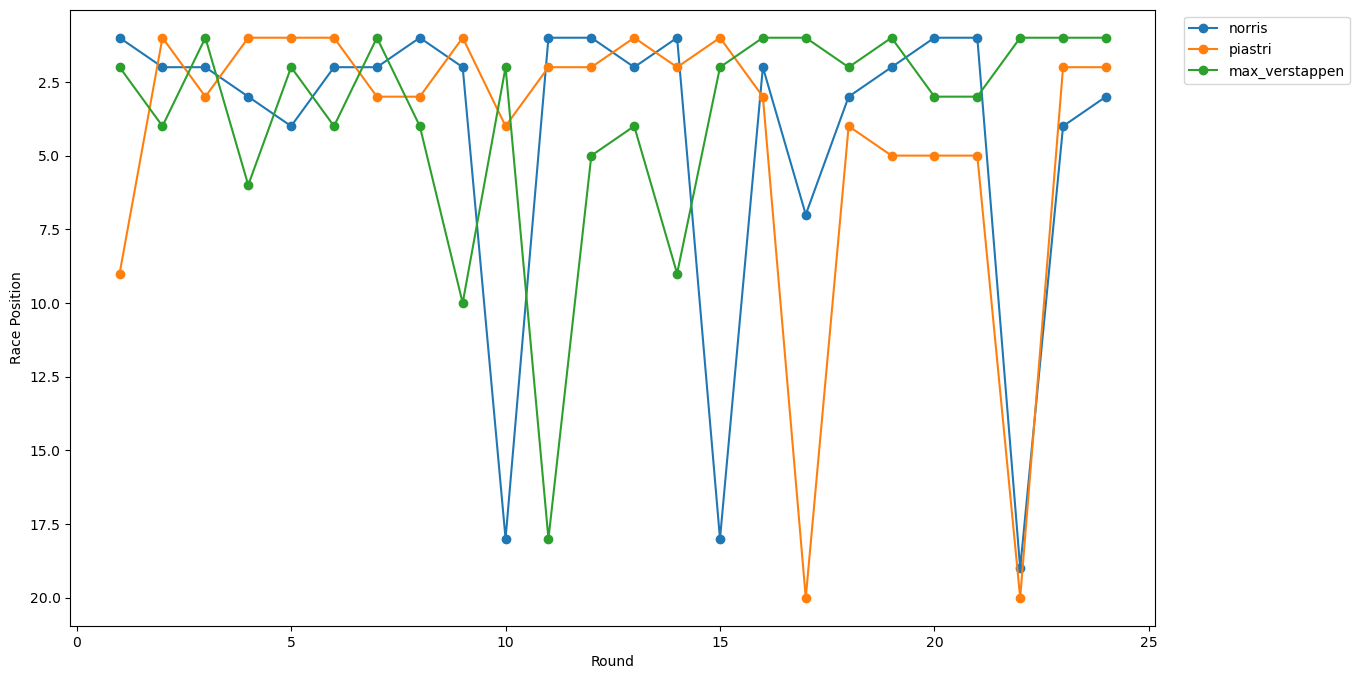

In [76]:
#plotting the chart of all drivers positions in each round in 2025
fig, ax = plt.subplots(figsize=(14, 8))

#for legibility purposes, the plot will only show the performances for the main title challengers in 2025
for driver in ['norris', 'piastri', 'max_verstappen']:
    ax.plot(pivot.index, driver_pivot[driver], marker='o', label=driver)

ax.invert_yaxis()
plt.xlabel('Round')
plt.ylabel('Race Position')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=10)
plt.show()

Given the nature of the 2025 season title charge, the most intriguing takeaway would be Piastri's apparent dip in form as the season came to an end. While he was consistent for most the season, where he looked as the clear cut favourite, a string of underwhelming results, plus 2 outliers where he finished last not only cost him the title but also second place as he finished in third. Norris (the eventual drivers champion), was more inconsistent throughout the season, but was relatively consistent when it mattered, especially with 2 race wins from the last 5 races. Defending champion, Verstappen struggled with his car for much of the season, but ultimately had the strongest season finish, winning the last 3 races of the season. Now, while this doesn't prove that certain drivers are better under pressure, given that there are other factors that impact a drivers position in a race, it does still give insight especially during the crucial moments in the season, of the drivers that are more likely to raise their performance.

In [93]:
#changes in a teams performance as a season progresses 2025
constructor_season = df[df['season']==2025]
constructor_pivot = constructor_season.pivot_table(
    index='round',
    columns='Constructor.constructorId',
    values='position',
    aggfunc='mean'
)
constructor_pivot

Constructor.constructorId,alpine,aston_martin,ferrari,haas,mclaren,mercedes,rb,red_bull,sauber,williams
round,,,,,,,,,,
1,15.0,11.5,9.0,13.5,5.0,3.5,16.0,8.5,11.5,11.5
2,16.5,13.0,18.5,6.5,1.5,4.5,13.5,8.0,14.5,8.5
3,14.0,15.5,5.5,14.0,2.5,5.5,12.5,6.5,17.5,11.5
4,10.5,16.0,4.5,9.0,2.0,6.5,14.5,7.5,19.0,15.5
5,18.5,13.5,5.0,13.5,2.5,5.5,11.0,10.5,16.5,8.5
6,16.5,15.5,7.5,15.5,1.5,4.5,14.0,7.0,16.0,7.0
7,14.5,13.0,5.0,18.5,2.5,13.0,11.5,5.5,15.0,6.5
8,16.5,17.0,3.5,9.5,2.0,14.5,7.0,10.5,15.0,9.5
9,11.5,9.0,4.5,16.5,1.5,11.0,9.0,11.5,8.5,16.5


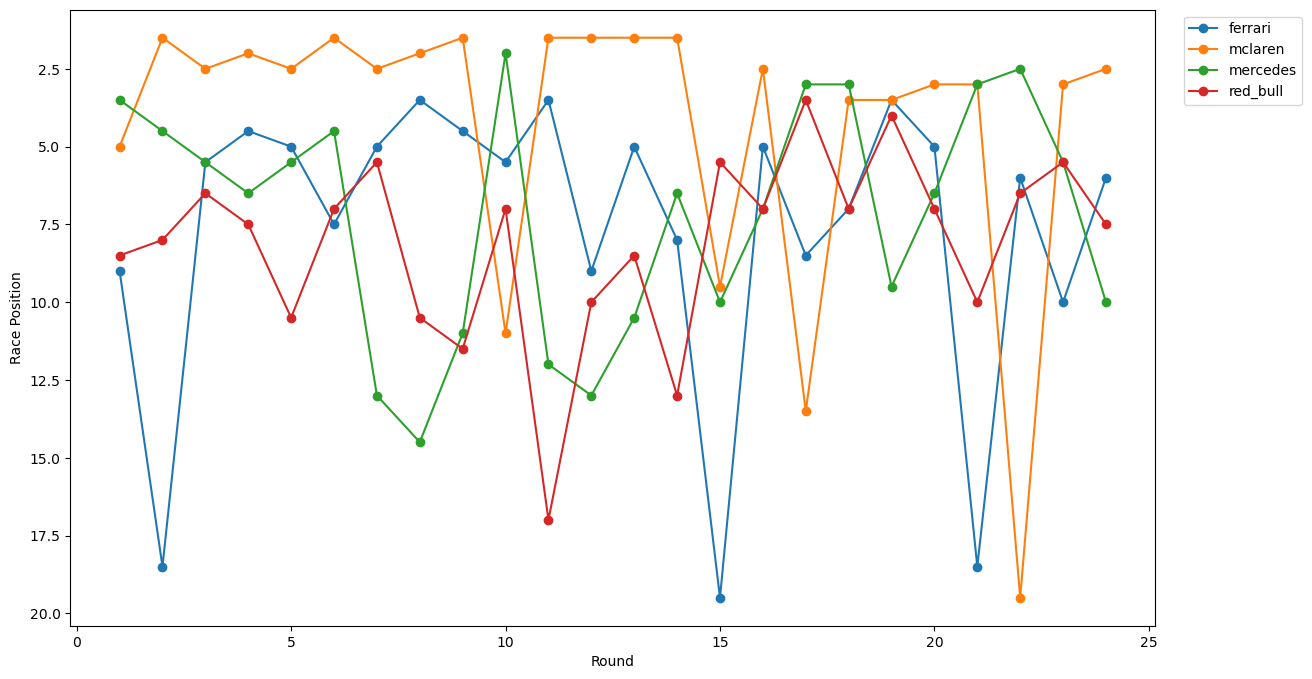

In [75]:
#plotting the chart of all drivers positions in each round in 2025
fig, ax = plt.subplots(figsize=(14, 8))

#for legibility purposes, the plot will only show the performances for the main title challengers in 2025
for team in ['ferrari', 'mclaren', 'mercedes', 'red_bull']:
    ax.plot(pivot.index, constructor_pivot[team], marker='o', label=team)

ax.invert_yaxis()
plt.xlabel('Round')
plt.ylabel('Race Position')
ax.legend(bbox_to_anchor=(1.02,1), loc='upper left', fontsize=10)
plt.show()

In [94]:
#changes in a teams performance as a season progresses 2024
constructor_season = df[df['season']==2024]
constructor_pivot = constructor_season.pivot_table(
    index='round',
    columns='Constructor.constructorId',
    values='position',
    aggfunc='mean'
)
constructor_pivot

Constructor.constructorId,alpine,aston_martin,ferrari,haas,mclaren,mercedes,rb,red_bull,sauber,williams
round,,,,,,,,,,
1,17.5,9.5,3.5,14.0,7.0,6.0,13.5,1.5,15.0,17.5
2,16.5,12.0,5.0,11.0,6.0,7.5,15.5,1.5,17.5,12.5
3,14.5,7.0,1.5,9.5,3.5,17.5,9.5,12.0,14.5,11.0
4,15.5,9.0,3.5,12.0,6.5,8.0,14.5,1.5,16.0,18.5
5,12.0,11.0,4.5,13.0,5.0,7.5,18.5,2.0,17.0,14.5
6,11.0,13.0,4.0,15.0,7.0,7.0,11.0,3.0,15.0,19.0
7,15.0,14.0,4.0,11.5,3.0,6.5,11.5,4.5,16.5,18.5
8,13.5,12.5,2.0,19.5,3.0,6.0,10.0,12.0,14.5,12.0
9,9.5,6.5,17.5,11.5,3.5,3.5,11.0,9.5,14.0,18.5


In [98]:
#changes in a teams performance as a season progresses 2023
constructor_season = df[df['season']==2023]
constructor_pivot = constructor_season.pivot_table(
    index='round',
    columns='Constructor.constructorId',
    values='position',
    aggfunc='mean'
)
constructor_pivot

Constructor.constructorId,alfa,alphatauri,alpine,aston_martin,ferrari,haas,mclaren,mercedes,red_bull,williams
round,,,,,,,,,,
1,12.0,12.5,13.5,4.5,11.5,14.0,18.5,6.0,1.5,11.0
2,15.5,12.5,8.5,11.5,6.5,11.0,16.0,4.5,1.5,17.5
3,10.0,12.5,13.5,3.5,16.0,12.0,7.0,10.0,3.0,17.5
4,18.5,15.0,14.5,5.5,4.0,15.0,10.0,7.0,1.5,14.0
5,14.5,14.5,8.5,7.5,6.0,12.5,18.0,5.0,1.5,17.0
6,12.0,13.5,5.0,11.0,7.0,18.0,9.5,4.5,8.5,16.0
7,14.0,13.0,9.0,6.5,8.0,16.5,15.0,2.5,2.5,18.0
8,13.0,16.0,10.0,5.5,4.5,16.0,12.0,11.0,3.5,13.5
9,13.5,18.0,12.0,7.0,4.0,19.0,10.0,7.5,2.0,12.0


In [97]:
#changes in a teams performance as a season progresses 2022
constructor_season = df[df['season']==2022]
constructor_pivot = constructor_season.pivot_table(
    index='round',
    columns='Constructor.constructorId',
    values='position',
    aggfunc='mean'
)
constructor_pivot

Constructor.constructorId,alfa,alphatauri,alpine,aston_martin,ferrari,haas,mclaren,mercedes,red_bull,williams
round,,,,,,,,,,
1,8.0,14.0,8.0,14.5,1.5,8.0,14.5,3.5,18.5,14.5
2,13.0,13.5,11.0,12.5,2.5,14.5,12.0,7.5,2.5,16.0
3,9.5,12.0,12.0,15.5,10.5,13.5,5.5,3.5,10.0,13.0
4,10.0,9.5,16.5,9.0,13.0,13.0,10.5,8.5,1.5,13.5
5,13.5,15.0,9.5,13.5,2.5,15.5,16.0,5.5,2.5,11.5
6,12.5,11.5,8.0,13.0,12.0,15.5,10.0,4.0,1.5,17.0
7,12.5,14.0,9.5,12.0,3.0,19.5,9.5,6.5,2.0,16.5
8,14.5,9.0,8.5,11.0,19.5,15.5,8.5,3.5,1.5,13.5
9,7.5,16.0,7.5,11.0,3.5,18.0,13.0,3.5,10.5,14.5


The 2026 season so far

In [88]:
driver_season_2022 = df[df['season']==2026]
driver_pivot = driver_season_2022.pivot(
    index='round',
    columns='Driver.driverId',
    values='position'
)
driver_pivot

Driver.driverId,albon,alonso,antonelli,arvid_lindblad,bearman,bortoleto,bottas,colapinto,gasly,hadjar,...,lawson,leclerc,max_verstappen,norris,ocon,perez,piastri,russell,sainz,stroll
round,,,,,,,,,,,,,,,,,,,,,
1,12,18,2,8,7,9,19,14,10,20,...,13,3,6,5,11,16,21,1,15,17
2,22,17,1,12,5,21,13,10,6,8,...,7,4,16,20,14,15,19,2,9,18
3,20,18,1,14,22,13,19,16,7,12,...,9,3,8,5,10,17,2,4,15,21
4,10,15,1,14,11,12,18,7,21,22,...,20,8,5,2,13,16,3,4,9,17
5,21,20,1,22,10,13,16,6,8,5,...,7,4,3,18,14,17,11,19,9,15
6,8,10,1,7,20,11,21,14,3,4,...,6,17,22,19,9,15,5,12,16,18


In [91]:
#2026 drivers standing so far
df[df['season']==2026].groupby(['Driver.driverId'])['points'].sum().sort_values(ascending=False)

Driver.driverId
antonelli         143
hamilton           79
russell            67
leclerc            58
piastri            43
norris             38
max_verstappen     37
gasly              34
hadjar             26
lawson             22
bearman            17
colapinto          15
arvid_lindblad     10
sainz               6
albon               5
ocon                3
bortoleto           2
alonso              1
hulkenberg          0
perez               0
bottas              0
stroll              0
Name: points, dtype: int64

In [92]:
#2026 constructor standings so far
df[df['season']==2026].groupby(['Constructor.constructorId'])['points'].sum().sort_values(ascending=False)

Constructor.constructorId
mercedes        210
ferrari         137
mclaren          81
red_bull         63
alpine           49
rb               32
haas             20
williams         11
audi              2
aston_martin      1
cadillac          0
Name: points, dtype: int64

In [89]:
#changes in a teams performance as a season progresses
constructor_season = df[df['season']==2026]
constructor_pivot = constructor_season.pivot_table(
    index='round',
    columns='Constructor.constructorId',
    values='position',
    aggfunc='mean'
)
constructor_pivot

Constructor.constructorId,alpine,aston_martin,audi,cadillac,ferrari,haas,mclaren,mercedes,rb,red_bull,williams
round,,,,,,,,,,,
1,12.0,17.5,15.5,17.5,3.5,9.0,13.0,1.5,10.5,13.0,13.5
2,8.0,17.5,16.0,14.0,3.5,9.5,19.5,1.5,9.5,12.0,15.5
3,11.5,19.5,12.0,18.0,4.5,16.0,3.5,2.5,11.5,10.0,17.5
4,14.0,16.0,15.5,17.0,7.0,12.0,2.5,2.5,17.0,13.5,9.5
5,7.0,17.5,12.5,16.5,3.0,12.0,14.5,10.0,14.5,4.0,15.0
6,8.5,14.0,12.0,18.0,9.5,14.5,12.0,6.5,6.5,13.0,12.0


## Overall Analysis

The data suggests that during the ground effect era, Redbull would be the team to beat with Max Verstappen being the driver to beat, given Redbull won the constructor championships from 2022-2023 and Verstappen the drivers championships from 2022-2024. Mclaren seem to be the team to beat recently, with back-to-back championships in 2024 and 2025, and their driver Lando Norris being the most recent World Drivers Champion (WDC).
2026 however is different, with a complete set of regulations. This may ultimately switch up the order, given what we've already seen from the first few races of the season. Mercedes are comfortably the quickest team, winning all races so far, with Ferrari being their closest challengers this season.
The ineresting part is how the midfield has once again changed in 2026 thus far, with some teams outperforming their expectations like Haas, while Aston Martin has been relatively poor this season. Ultimately, for a prediction model, the only team that may be easy to predict would be Cadillac given that it's their first season in F1.